<a href="https://colab.research.google.com/github/oxedanda/avcad_final_project/blob/main/notebooks/02_full_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Agricultural Restructuring in Mainland Portugal
## Reproducible exploratory and inferential analysis, 1989-2019

This notebook asks how mainland Portuguese agriculture changed across four Agricultural Census years. The processed extracts contain national mainland totals only, so the analysis is temporal rather than regional. It combines labour, agricultural area, holdings reporting temporary and permanent crops, permanent grasslands, and crop productivity.

In [1]:
# prompt: Make the final AVCAD analysis reproducible in a clean Colab session.
from pathlib import Path
REPO_DIR = Path("/content/avcad_final_project")
if REPO_DIR.exists():
    %cd /content/avcad_final_project
    !git pull --ff-only
else:
    !git clone https://github.com/oxedanda/avcad_final_project.git /content/avcad_final_project
    %cd /content/avcad_final_project
!pip -q install -r requirements.txt

Cloning into '/content/avcad_final_project'...
remote: Enumerating objects: 152, done.
remote: Counting objects: 100% (152/152), done.
remote: Compressing objects: 100% (116/116), done.
remote: Total 152 (delta 54), reused 100 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (152/152), 1.35 MiB | 16.84 MiB/s, done.
Resolving deltas: 100% (54/54), done.
/content/avcad_final_project
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 910.8/910.8 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 93.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently 

## 1. Data audit and harmonisation

The analysis starts from the six processed INE-derived CSV files committed to the repository. The script verifies years, uniqueness, and geographic coverage before merging the structural indicators by census year.

In [2]:
from IPython.display import Image, display
from src.analysis import run_analysis

results = run_analysis()
display(results["core_summary"].round(3))

,year,agricultural_labour_people,agricultural_area_ha,temporary_crop_holdings,permanent_crop_holdings,permanent_grasslands_ha,grasslands_ge_100ha,agricultural_area_per_worker_ha,grasslands_ge_100ha_share
0,1989,1449906,5157213,446915,453441,754825,461523,3.557,0.611
1,1999,1002480,5039569,280214,320484,1331033,925523,5.027,0.695
2,2009,649607,4571531,165265,225806,1721587,1306976,7.037,0.759
3,2019,596938,4987658,124902,205208,2003795,1474004,8.355,0.736


## 2. Descriptive changes

The 1989-2019 comparison quantifies the direction and magnitude of structural change. Agricultural area per worker is used instead of the earlier 'average holding size by crop type', which could not be estimated validly from the available numerators and denominators.

,indicator,value_1989,value_2019,absolute_change,percent_change
0,Agricultural labour,1449906.00,596938.00,-852968.00,-58.83
1,Agricultural area,5157213.00,4987658.00,-169555.00,-3.29
2,Holdings with temporary crops,446915.00,124902.00,-322013.00,-72.05
3,Holdings with permanent crops,453441.00,205208.00,-248233.00,-54.74
4,Permanent grasslands and pastures,754825.00,2003795.00,1248970.00,165.46
5,Agricultural area per worker,3.56,8.36,4.80,134.90
6,Share of grasslands in >=100 ha class,0.61,0.74,0.12,20.31


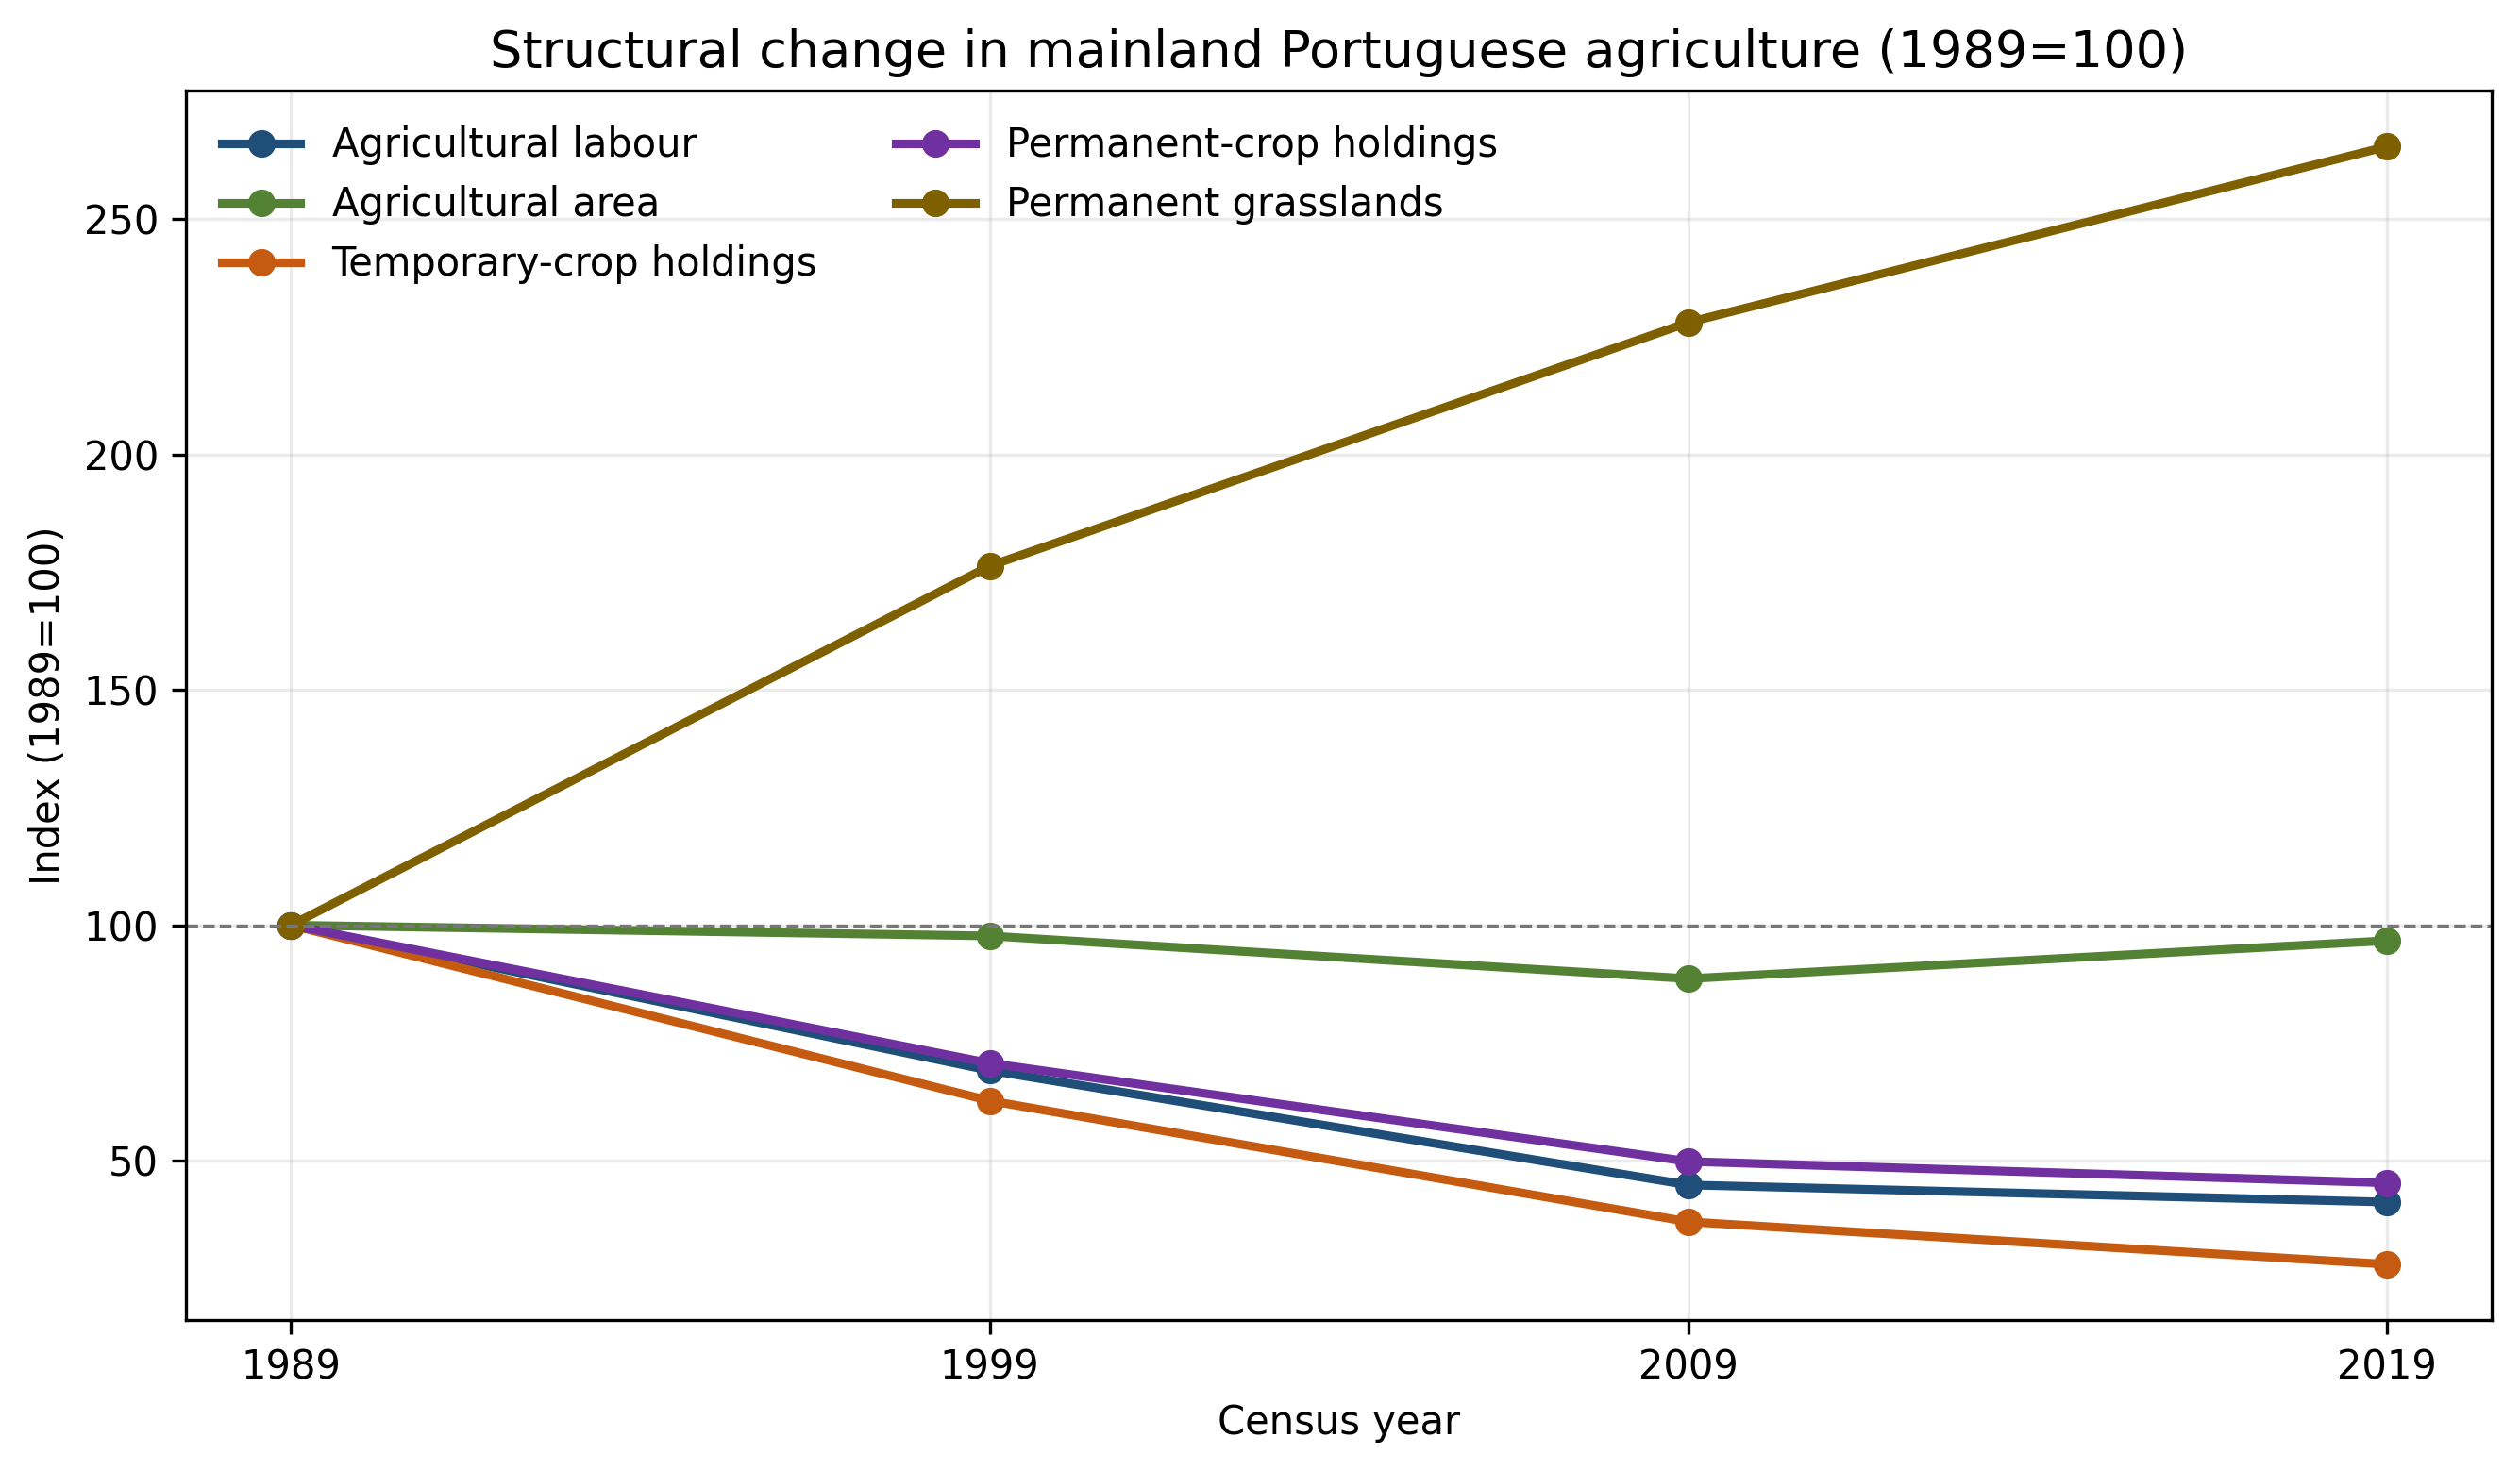

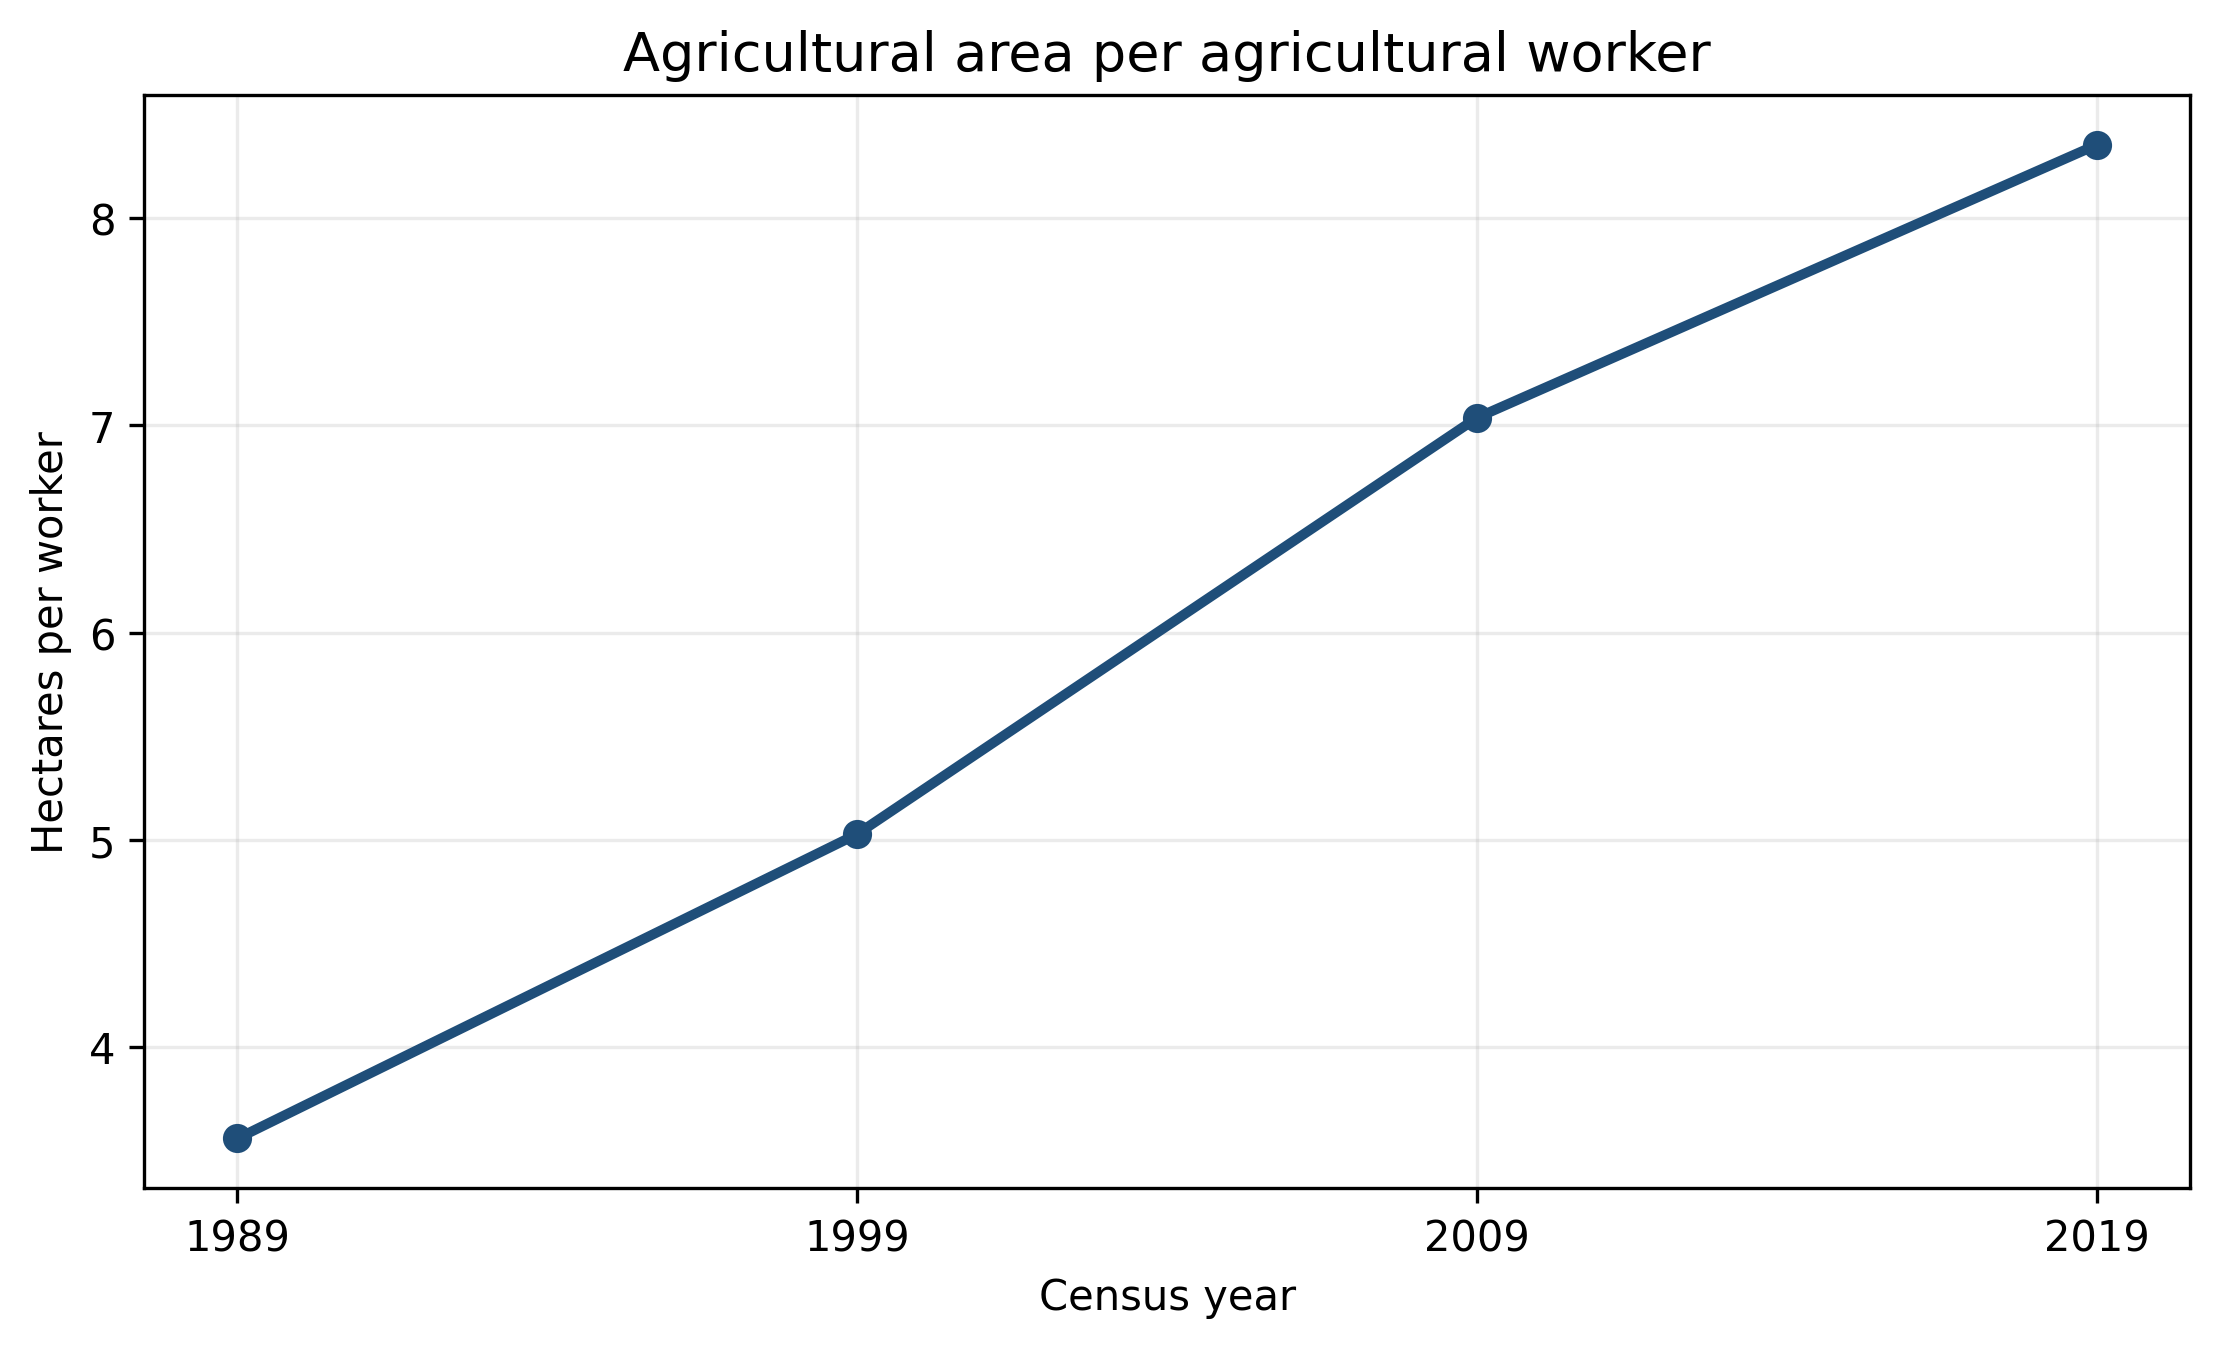

In [3]:
display(results["percent_change"].round(2))
display(Image(filename="outputs/figures/indexed_structural_change.png", width=900))
display(Image(filename="outputs/figures/area_per_worker.png", width=760))

## 3. Crop systems, grasslands, and productivity

The number of holdings reporting temporary crops declined faster than the number reporting permanent crops. Permanent grasslands expanded strongly, especially in the largest area class. Productivity changes were heterogeneous across crop groups.

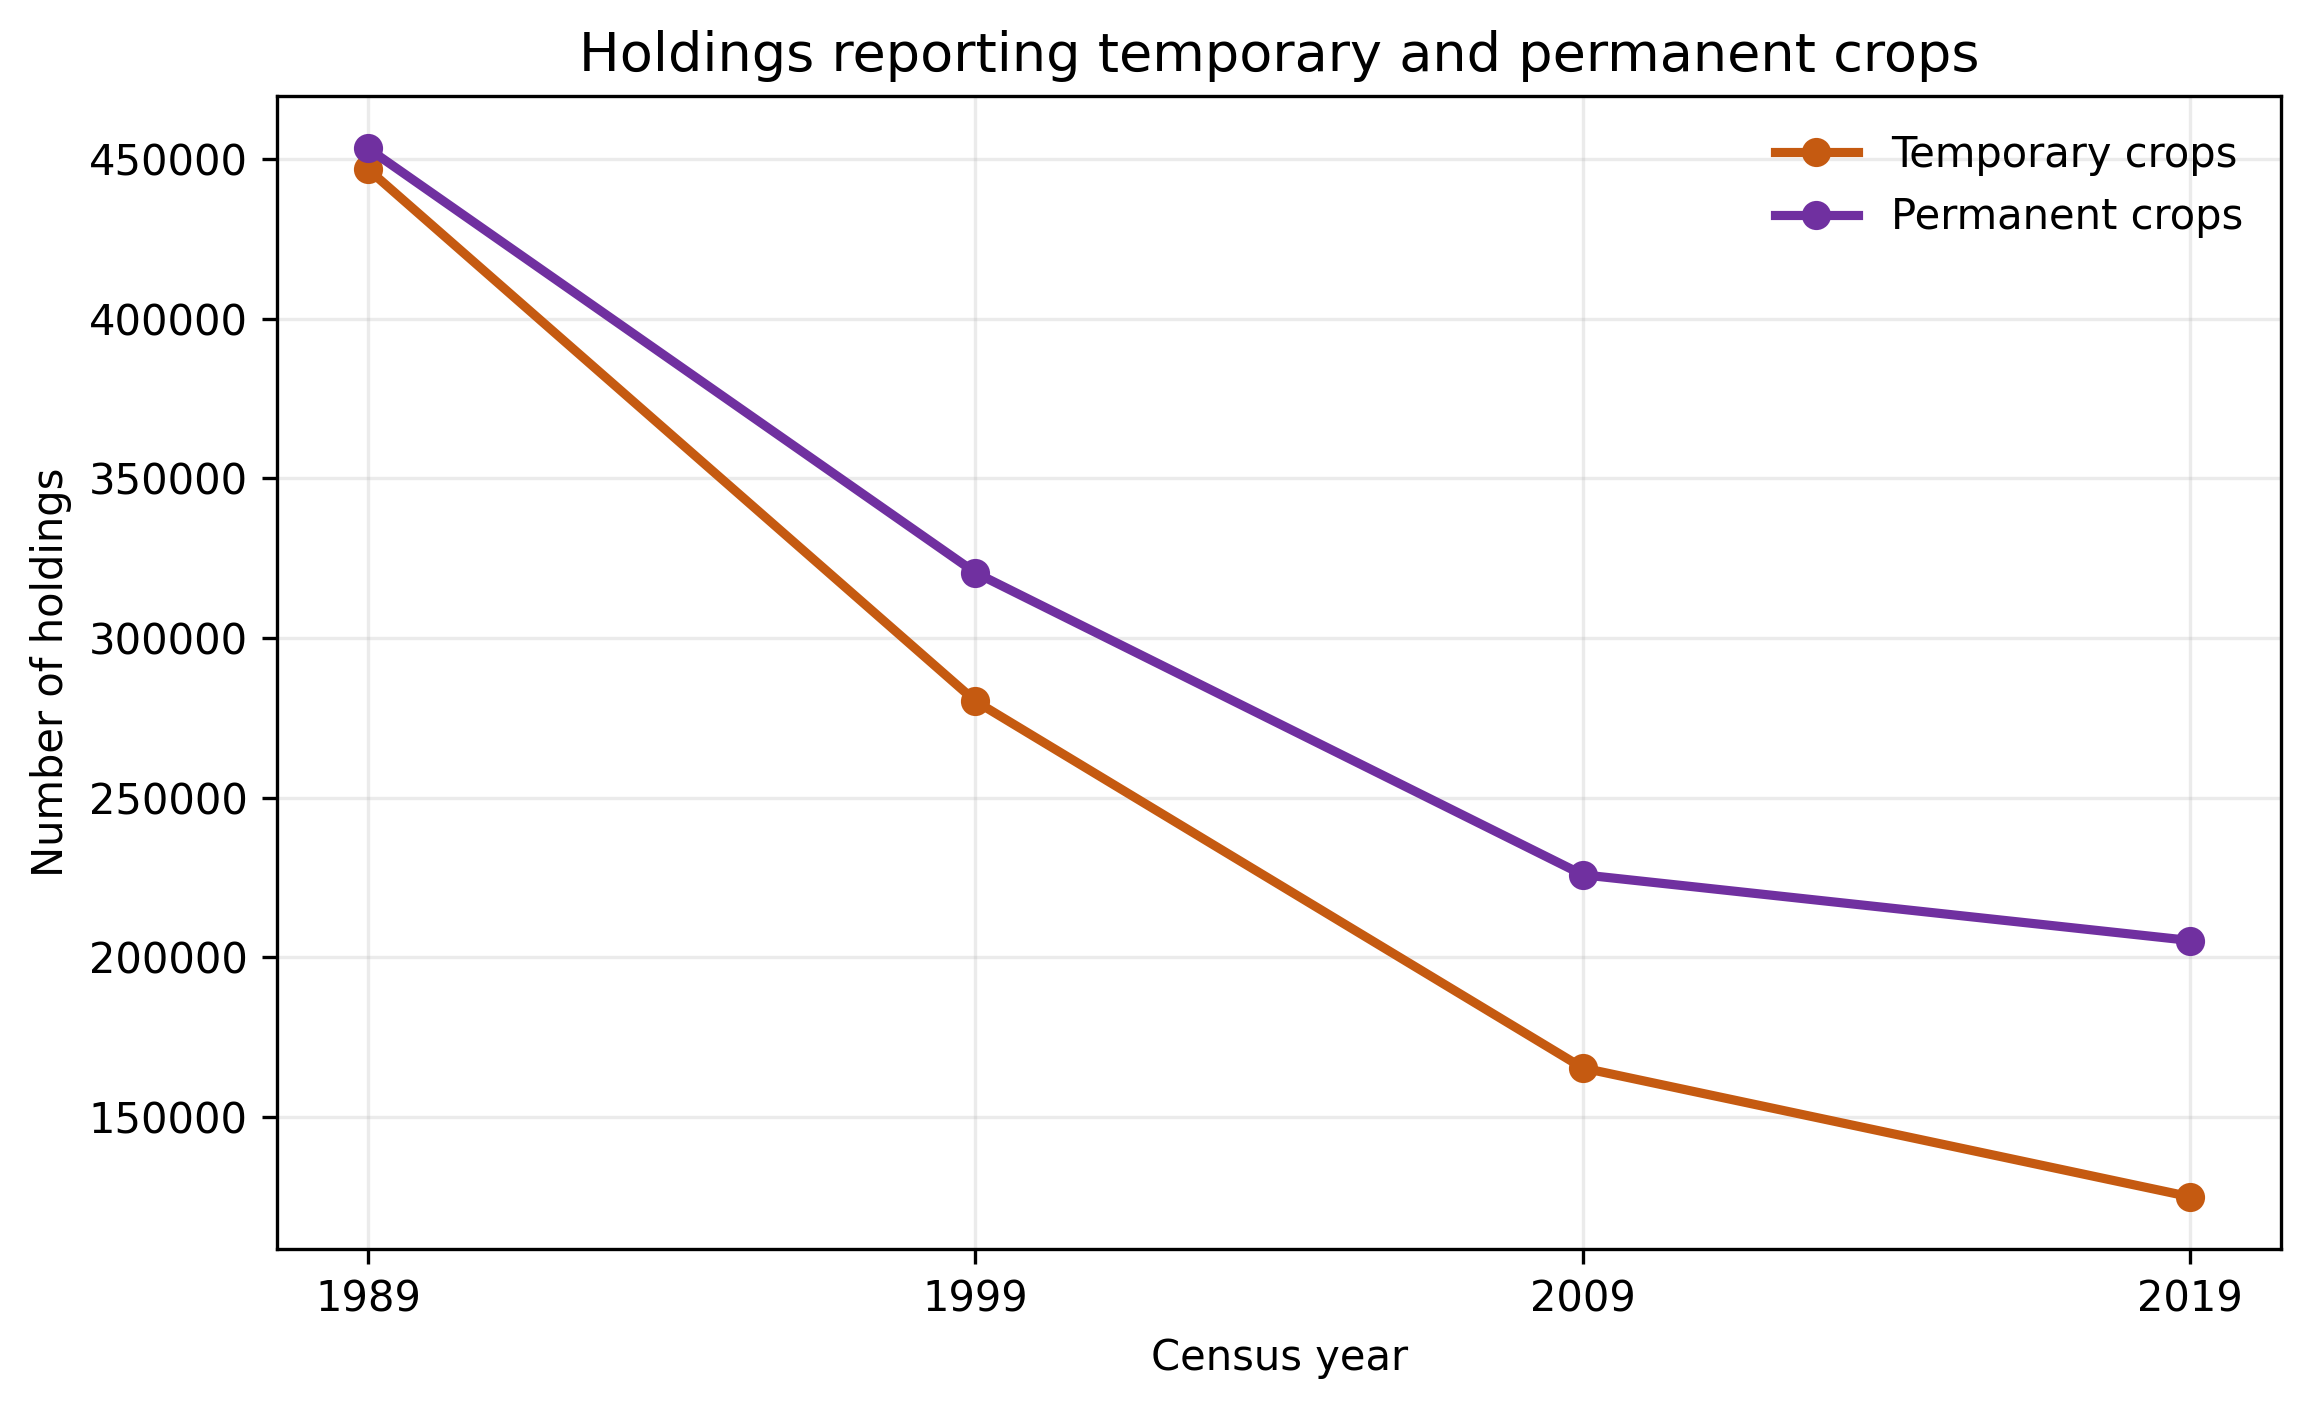

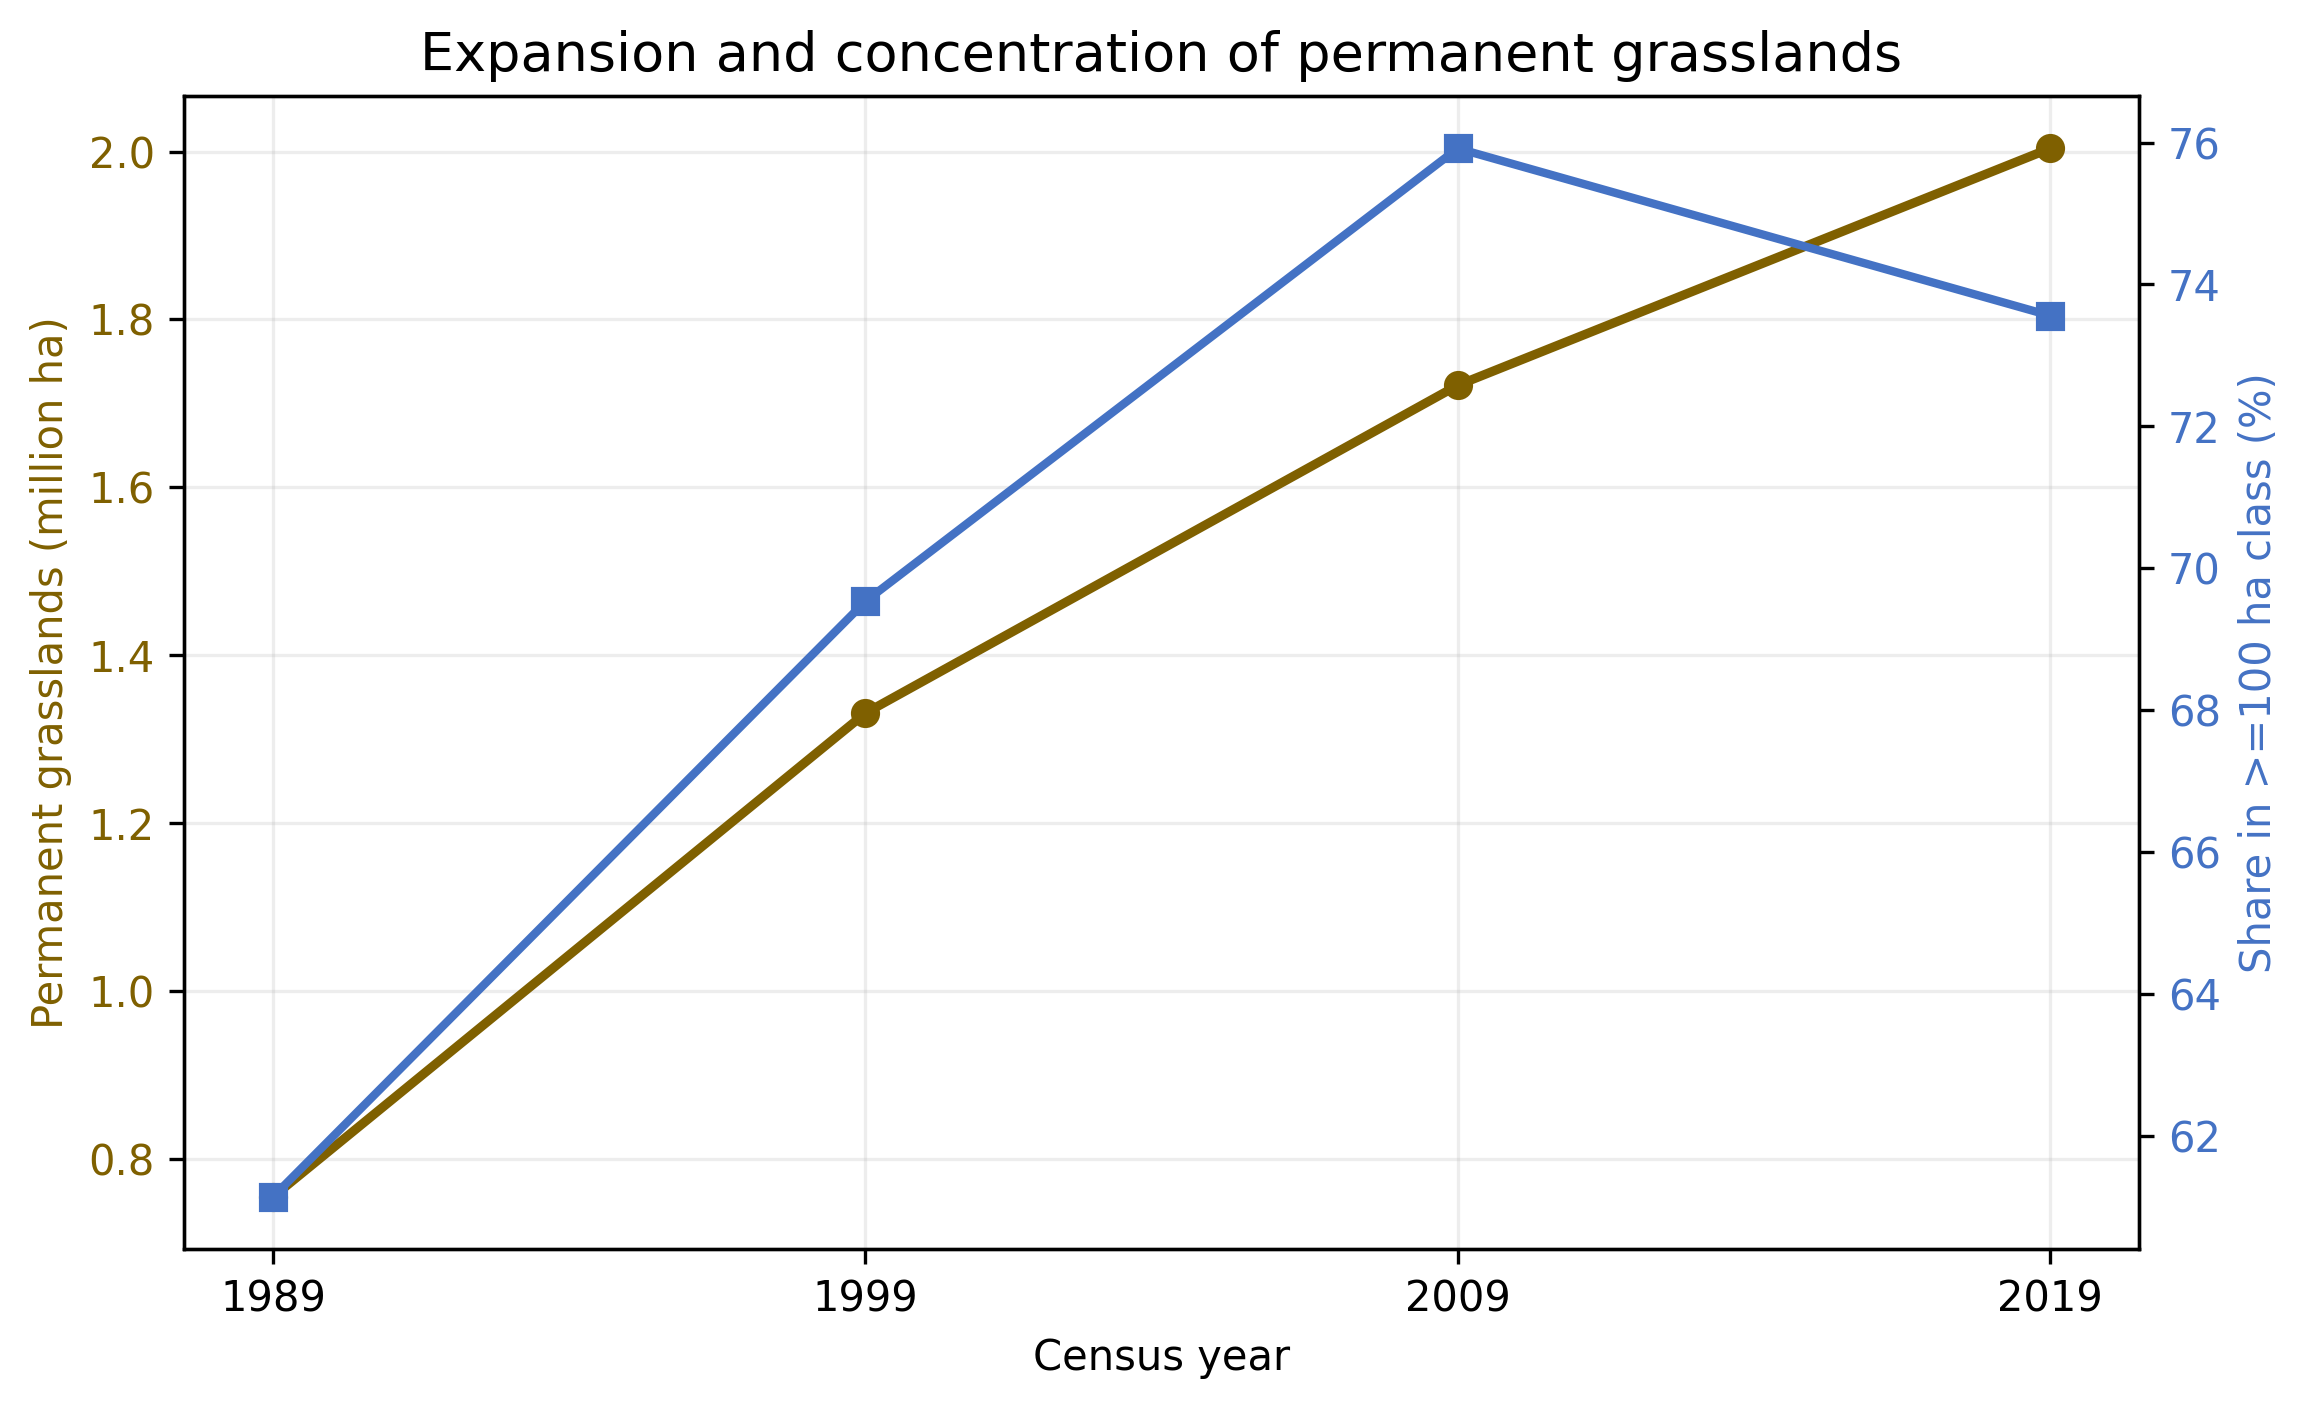

,crop_group,productivity_1989_kg_ha,productivity_2019_kg_ha,percent_change
3,Main crops for industry,9303.0,65754.0,606.80
4,Small berries,3773.0,10508.0,178.51
0,Cereals for grain,2013.0,5160.0,156.33
8,Olive groves,971.0,2481.0,155.51
5,Citrus fruits,7791.0,19460.0,149.78
2,Potatoes,11209.0,22953.0,104.77
1,Main dried legumes,560.0,797.0,42.32
7,Vineyards,4003.0,4948.0,23.61
6,Main nut fruits,1325.0,772.0,-41.74


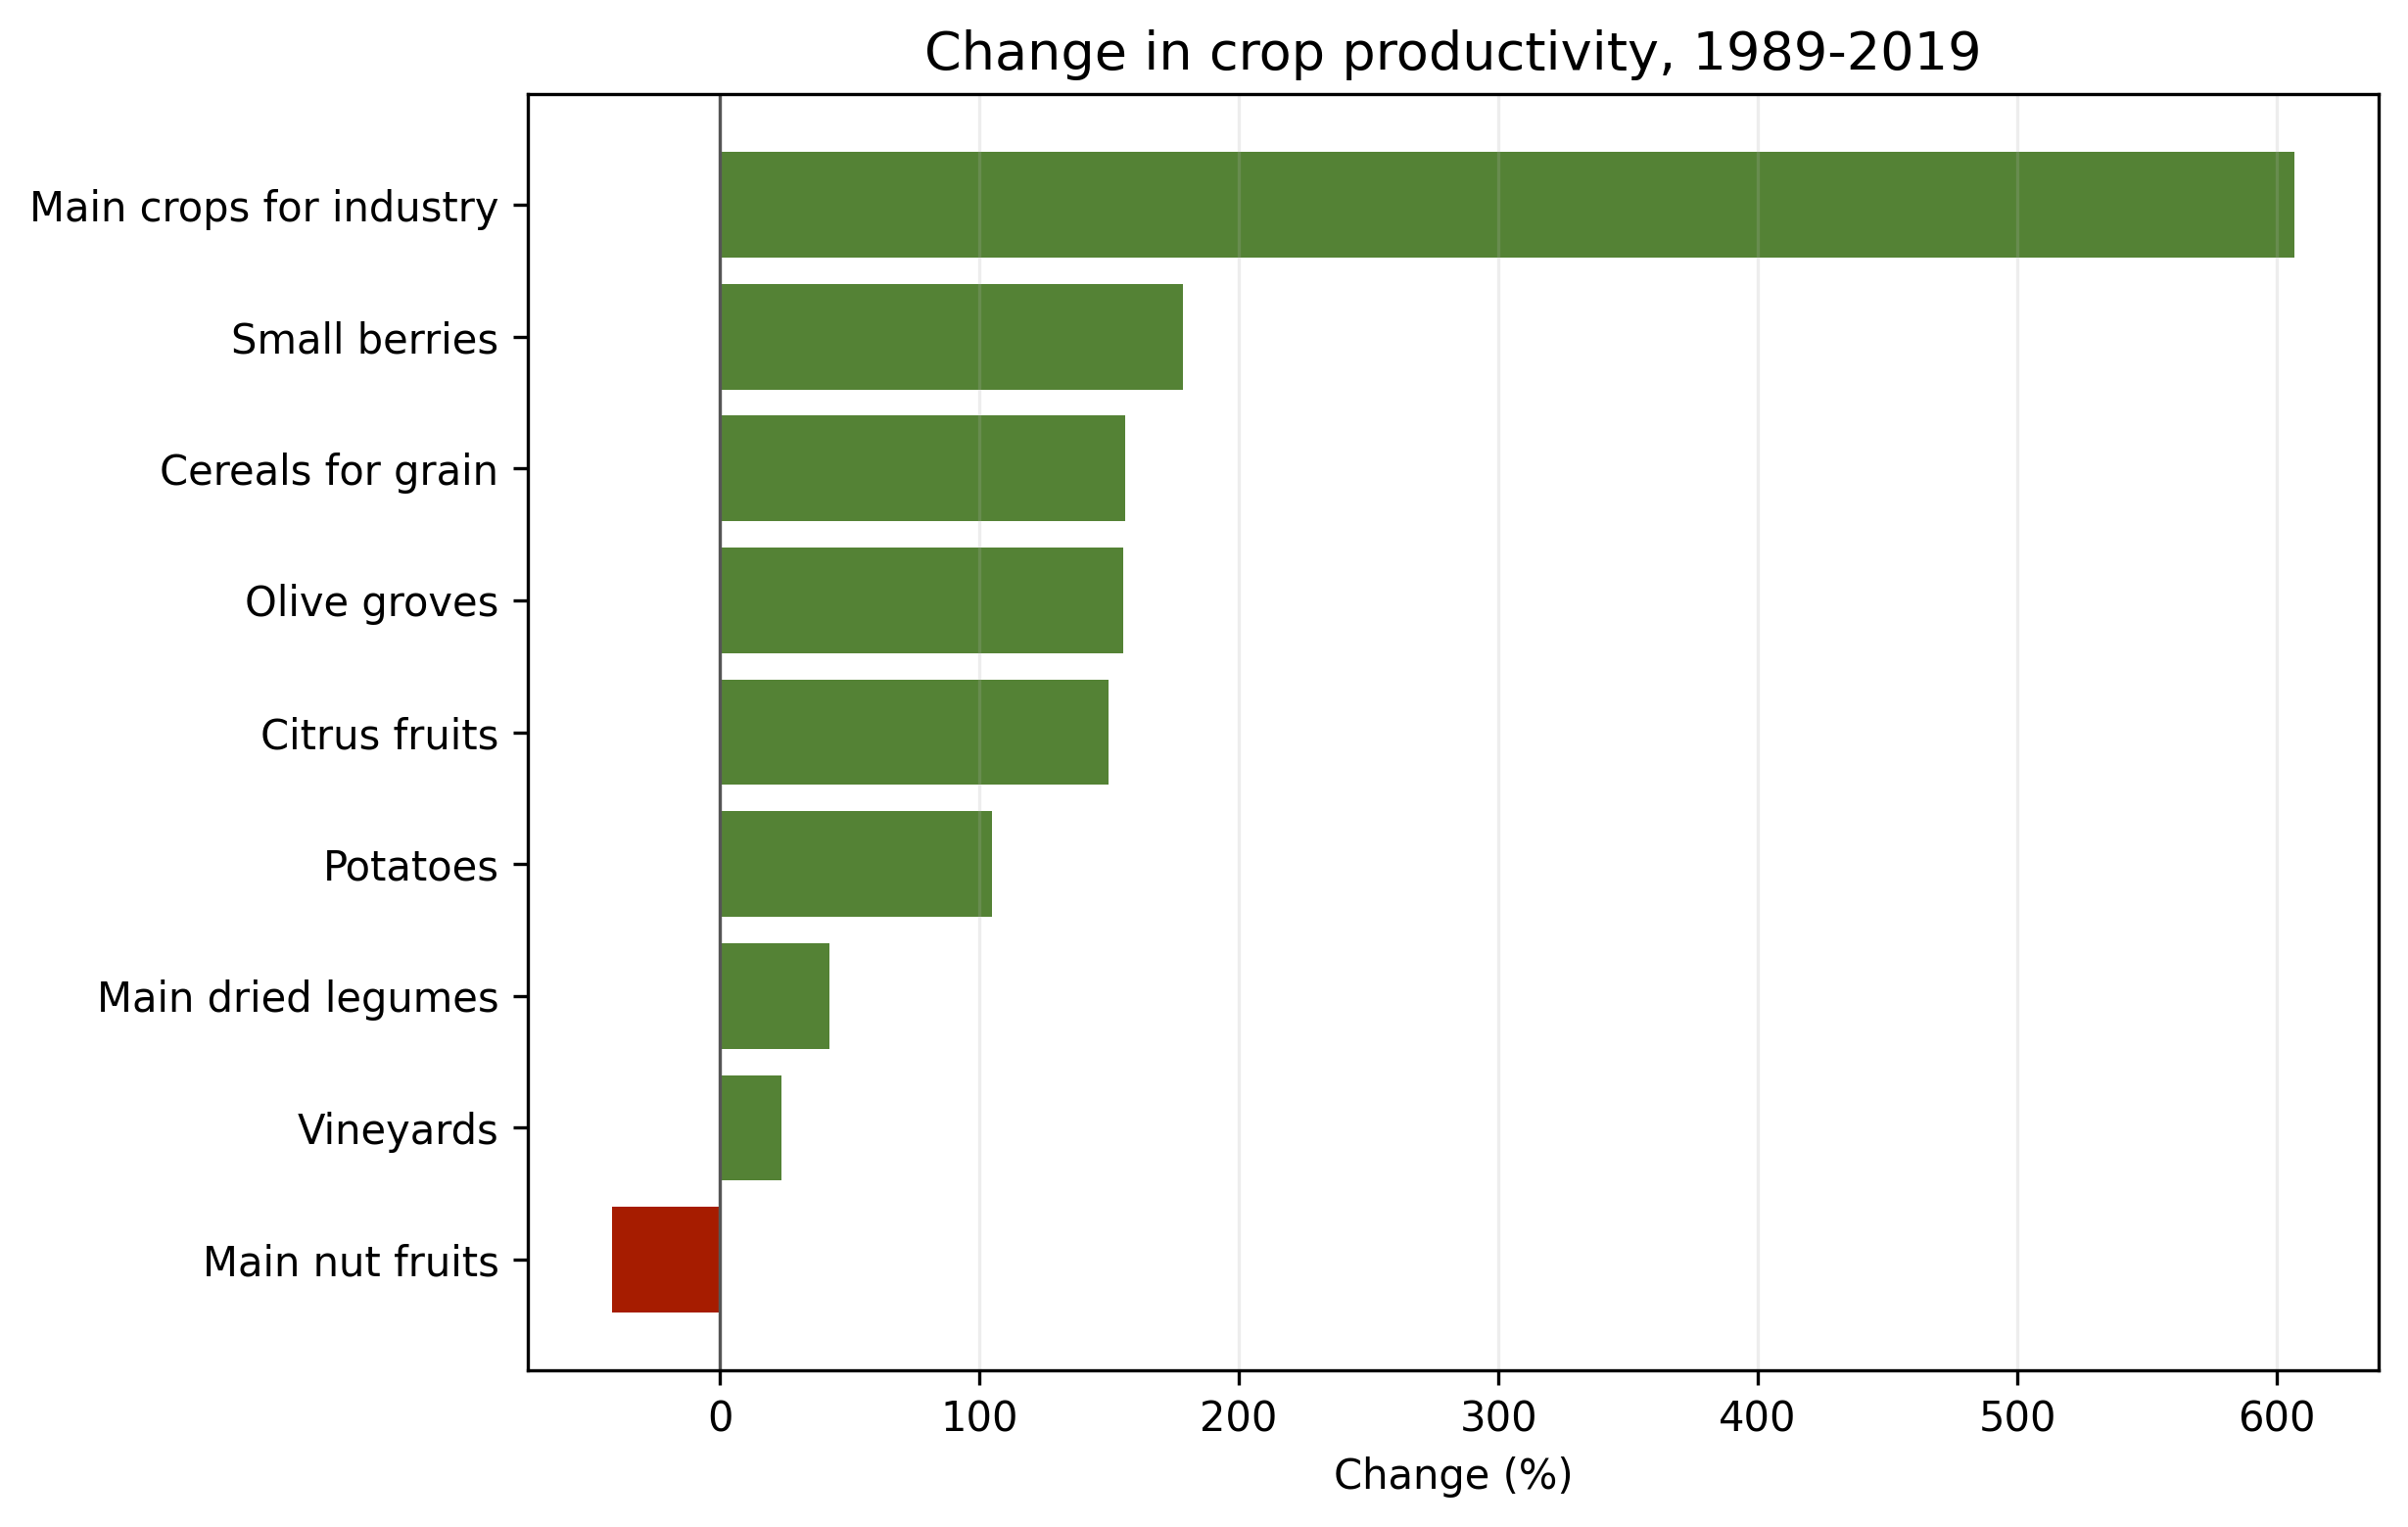

In [4]:
display(Image(filename="outputs/figures/crop_holdings.png", width=780))
display(Image(filename="outputs/figures/grasslands_change.png", width=780))
display(results["productivity_change"].round(2))
display(Image(filename="outputs/figures/productivity_change.png", width=820))

## 4. Inferential statistics

Ordinary least-squares trend tests and Spearman correlations are reported because inferential statistics are required by the project brief. They must be interpreted cautiously: each census indicator has only four observations, giving two residual degrees of freedom. P-values describe compatibility with a simple linear trend under strong assumptions; they do not establish causality or remove uncertainty about structural breaks.

In [5]:
display(results["trend_tests"].round(4))
display(results["hypothesis_assessment"])

,indicator,n,ols_slope_per_decade,slope_ci95_low,slope_ci95_high,pearson_r,ols_p_value,r_squared,spearman_rho,spearman_p_value
0,Agricultural labour,4,-291177.7000,-566926.6839,-15428.7161,-0.9548,0.0452,0.9117,-1.0,0.0
1,Agricultural area,4,-97670.3000,-620109.9152,424769.3152,-0.4944,0.5056,0.2444,-0.8,0.2
2,Holdings with temporary crops,4,-108098.8000,-194327.9985,-21869.6015,-0.9673,0.0327,0.9357,-1.0,0.0
3,Holdings with permanent crops,4,-83937.7000,-161148.7019,-6726.6981,-0.9572,0.0428,0.9162,-1.0,0.0
4,Permanent grasslands and pastures,4,413746.4000,212357.3097,615135.4903,0.9874,0.0126,0.9750,1.0,0.0
5,Agricultural area per worker,4,1.6406,1.2516,2.0295,0.9970,0.0030,0.9940,1.0,0.0


,hypothesis,assessment,evidence
0,H1,Supported descriptively and by a negative line...,Labour changed -58.8% (OLS p=0.045).
1,H2,Partially supported,"Total area changed only -3.3%, but land-use co..."
2,H3,Supported descriptively,Temporary-crop holdings changed -72.1% versus ...
3,H4,Supported descriptively,"Permanent grasslands changed 165.5%, with incr..."
4,H5,Supported descriptively,Productivity changes differ substantially amon...


## 5. Main conclusion

Mainland Portuguese agriculture did not simply contract. Between 1989 and 2019, labour and the number of holdings reporting crops fell sharply, while total agricultural area remained comparatively stable, area per worker more than doubled, and permanent grasslands expanded. The combined evidence is consistent with restructuring toward less labour-intensive and larger-scale land management. Productivity trajectories differ across crop groups, so the transformation was not uniform. These are national temporal patterns; regional mechanisms require geographically disaggregated data.